In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
df = pd.read_csv("heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8634146341463415


In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[87 13]
 [15 90]]


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       100
           1       0.87      0.86      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



In [21]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, pred)
    )

<Figure size 600x500 with 0 Axes>

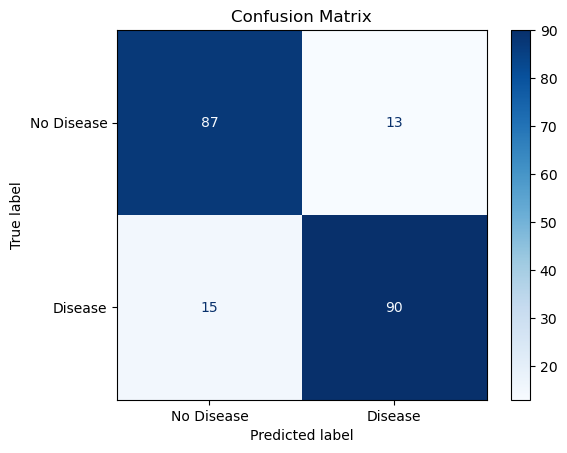

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

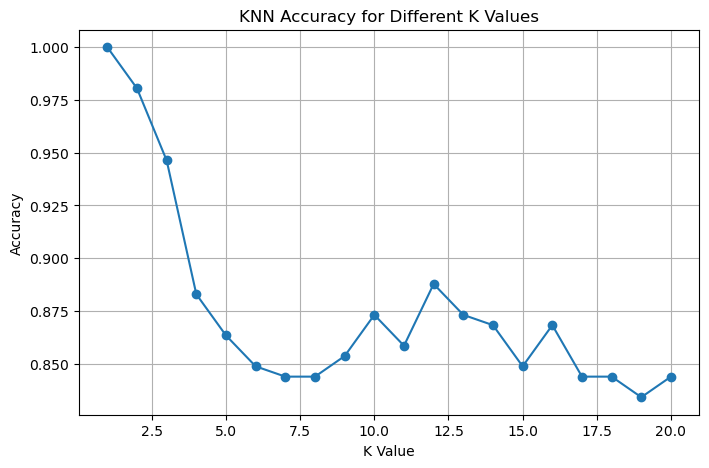

In [23]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")

plt.grid(True)

plt.show()

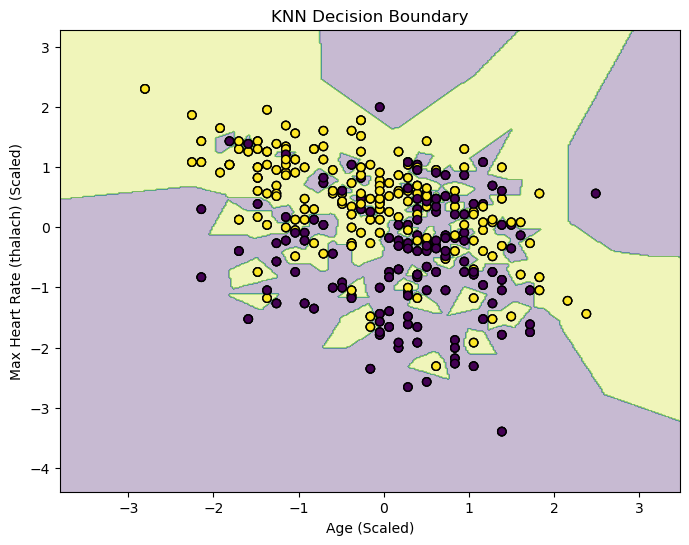

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Select only two features
X_vis = df[['age', 'thalach']]
y_vis = df['target']

# Scale features
scaler = StandardScaler()
X_vis_scaled = scaler.fit_transform(X_vis)

# Train KNN
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis_scaled, y_vis)

# Create mesh grid
x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn_vis.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

scatter = plt.scatter(
    X_vis_scaled[:, 0],
    X_vis_scaled[:, 1],
    c=y_vis,
    edgecolor='k'
)

plt.xlabel("Age (Scaled)")
plt.ylabel("Max Heart Rate (thalach) (Scaled)")
plt.title("KNN Decision Boundary")

plt.savefig("decision_boundary.png", bbox_inches="tight")
plt.show()

In [25]:
best_k = k_values[np.argmax(accuracies)]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 1
Best Accuracy: 1.0
